In [2]:
pip install pycirclize

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 19.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


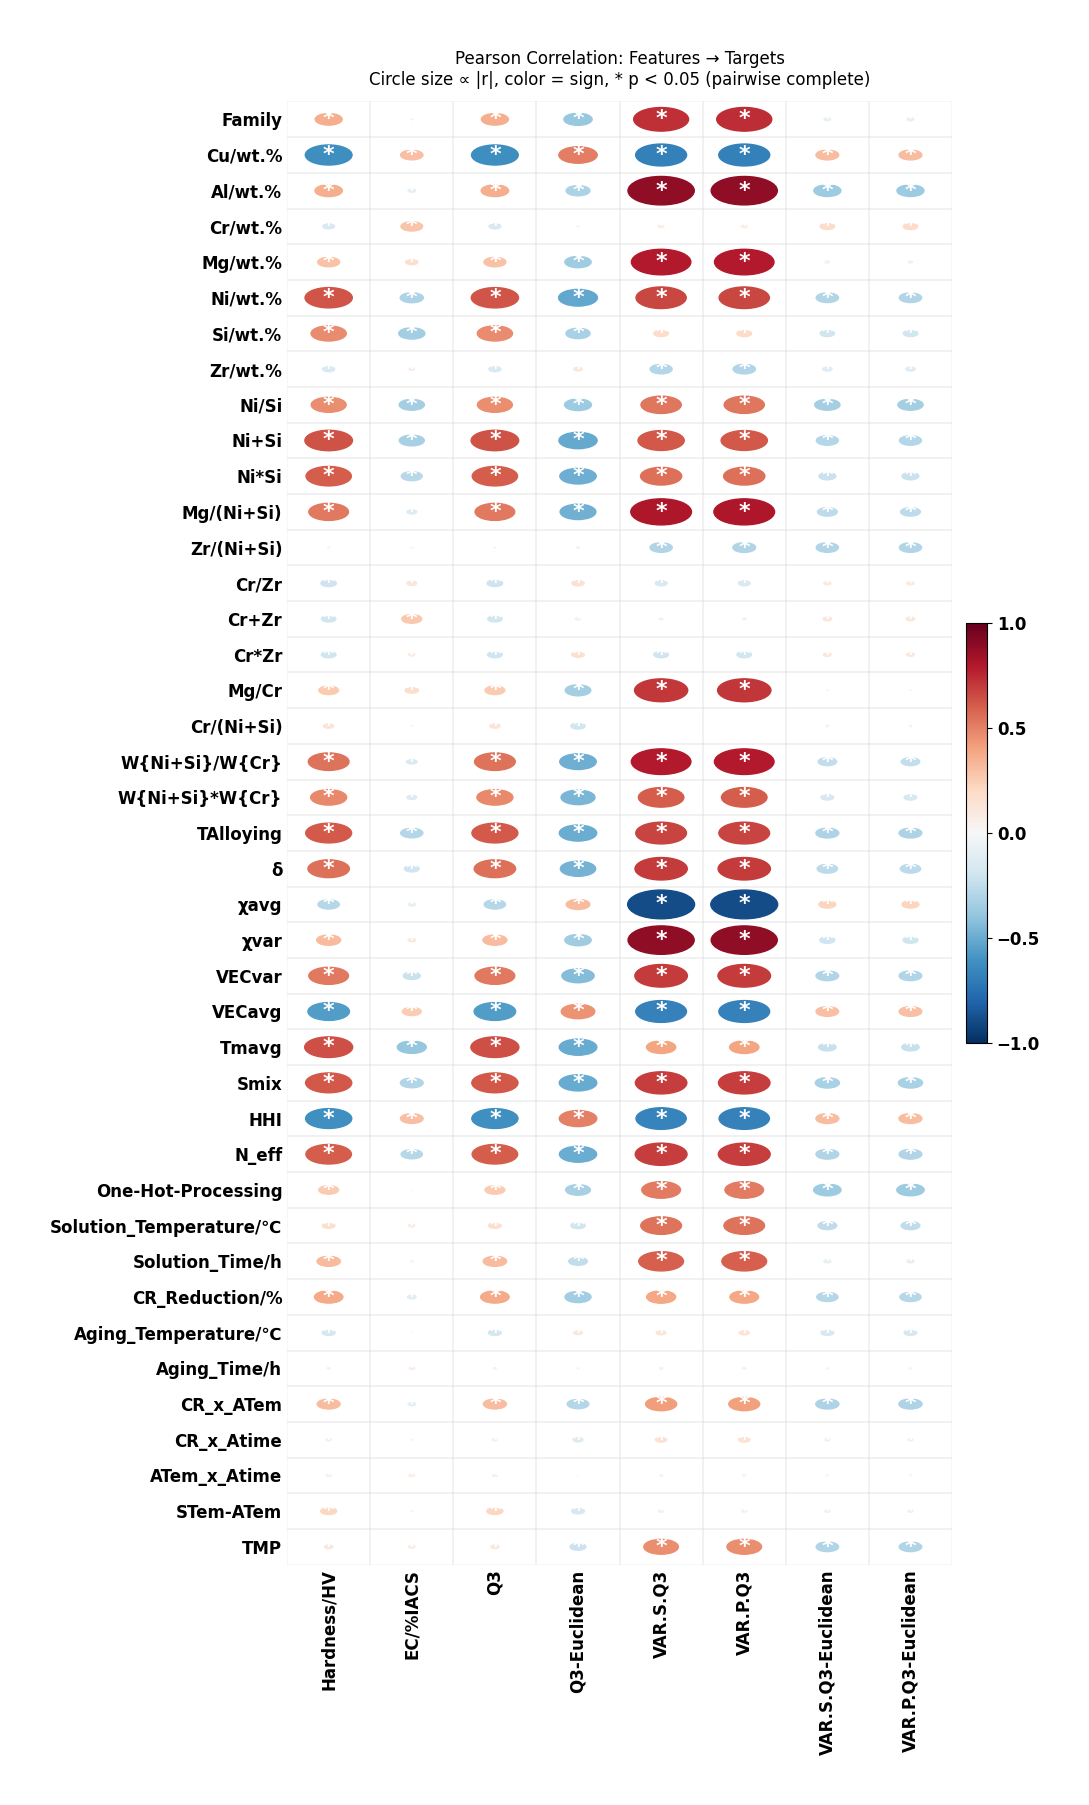

图像已保存至: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/feature_to_target_corr.png
矩阵已保存至: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/feature_to_target_corr.xlsx


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

# ── 1) 读取数据 ───────────────────────────────────────────────────────────────
df_raw = pd.read_excel(
    "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Feature.xlsx",
    sheet_name="Feature"
)

# ====================================================
# ✅ 在这里设置你的列范围（Python 从 0 开始计数）
# Feature: [feature_start, feature_end)
# Target : [target_start,  target_end)
# ====================================================
feature_start = 1     # 特征起始列索引（含）
feature_end   = 42    # 特征结束列索引（不含）
target_start  = 42    # 性能起始列索引（含）
target_end    = 51    # 性能结束列索引（不含）
# ====================================================

feature_cols = df_raw.columns[feature_start:feature_end]
target_cols  = df_raw.columns[target_start:target_end]

# 只保留这些列，并强制转数值（非数值→NaN）
df_sub = df_raw[list(feature_cols) + list(target_cols)].apply(pd.to_numeric, errors="coerce")

F = list(feature_cols)
T = list(target_cols)

# ── 2) 计算 Feature → Target 的 Pearson r / p / n ────────────────────────────
rmat = pd.DataFrame(index=F, columns=T, dtype=float)
pmat = pd.DataFrame(index=F, columns=T, dtype=float)
nmat = pd.DataFrame(index=F, columns=T, dtype=int)

for f in F:
    for t in T:
        pair = df_sub[[f, t]].dropna()
        n = len(pair)
        nmat.loc[f, t] = n

        if n < 2:
            rmat.loc[f, t] = np.nan
            pmat.loc[f, t] = np.nan
            continue

        r, p = stats.pearsonr(pair[f].values, pair[t].values)
        rmat.loc[f, t] = r
        pmat.loc[f, t] = p

# ── 3) 绘图：行=Feature，列=Target（影响大小矩阵）────────────────────────────
fig_w = max(6, 0.9 * len(T) + 3)
fig_h = max(6, 0.35 * len(F) + 3)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 颜色映射：蓝(-1) → 白(0) → 红(1)
cmap = plt.cm.RdBu_r
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# 先画网格背景（浅灰格子）
for i in range(len(F)):
    for j in range(len(T)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (j - 0.5, i - 0.5), 1, 1,
            boxstyle="square,pad=0",
            linewidth=0.3, edgecolor="#dddddd",
            facecolor="none", zorder=1
        ))

# 画圆点（大小∝|r|，颜色=sign），p<0.05 加星号
for i, f in enumerate(F):
    for j, t in enumerate(T):
        r = rmat.loc[f, t]
        p = pmat.loc[f, t]
        n = nmat.loc[f, t]

        if np.isnan(r):
            continue

        radius = abs(r) * 0.45
        color = cmap(norm(r))
        ax.add_patch(plt.Circle((j, i), radius, color=color, zorder=2))

        if (not np.isnan(p)) and p < 0.05:
            ax.text(j, i, "*", ha="center", va="center",
                    fontsize=16, color="white", fontweight="bold", zorder=3)

        # 可选：把样本数 n 写在圆点下方（想要就取消注释）
        # ax.text(j, i+0.28, f"n={n}", ha="center", va="center", fontsize=6, color="#555555", zorder=4)

# 坐标轴与标签
ax.set_xlim(-0.5, len(T) - 0.5)
ax.set_ylim(-0.5, len(F) - 0.5)
ax.set_xticks(range(len(T)))
ax.set_yticks(range(len(F)))

ax.set_xticklabels(T, rotation=90, ha="center", fontsize=12, fontweight="bold")
ax.set_yticklabels(F, fontsize=12, fontweight="bold")
ax.invert_yaxis()

# 去掉边框/刻度线
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# 颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.tick_params(labelsize=12)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

ax.set_title(
    "Pearson Correlation: Features → Targets\n"
    "Circle size ∝ |r|, color = sign, * p < 0.05 (pairwise complete)",
    fontsize=12, pad=12
)

plt.tight_layout()

# ── 4) 保存输出 ───────────────────────────────────────────────────────────────
out_png = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/feature_to_target_corr.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print("图像已保存至:", out_png)

# 同时导出矩阵（r/p/n）
out_xlsx = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/feature_to_target_corr.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as w:
    rmat.to_excel(w, sheet_name="Pearson_r")
    pmat.to_excel(w, sheet_name="p_value")
    nmat.to_excel(w, sheet_name="n_used")
print("矩阵已保存至:", out_xlsx)

In [2]:
from pycirclize import Circos
import numpy as np
import pandas as pd

# =======================
# 0) Read Excel
# =======================
excel_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/Corr.xlsx"
sheet_name = "Pearson_r"
df = pd.read_excel(excel_path, sheet_name=sheet_name)

# ---- Feature names (first column) ----
feature_names = df.iloc[:, 0].astype(str).tolist()

# ---- Numeric matrix (last 8 cols) ----
num_df = df.iloc[:, -8:].apply(pd.to_numeric, errors="coerce")
M = num_df.to_numpy()  # shape: (n_rows, 8)

# =======================
# 1) Define sectors by Excel row ranges (1-based, inclusive)
# =======================
ranges_1based = {
    "A": (21, 30),  # 10 rows
    "B": (2, 20),   # 19 rows
    "C": (32, 42),  # 11 rows
}
sectors = {k: (v[1] - v[0] + 1) for k, v in ranges_1based.items()}
circos = Circos(sectors, space=10)

# =======================
# 2) Track row labels (radial labels)
# =======================
track1_labels = ["HV", "EC"]
track2_labels = ["", "", "", ""]  # keep blanks if you want empty rows

# =======================
# 3) Color ranges (correlations)
# =======================
vmin1, vmax1 = -1, 1
vmin2, vmax2 = -1, 1

# =======================
# 4) Style params (统一管理，方便改)
# =======================
OUTER_LABEL_SIZE = 11
OUTER_LABEL_BOLD = True

RADIAL_LABEL_SIZE_T1 = 10
RADIAL_LABEL_SIZE_T2 = 11
RADIAL_LABEL_BOLD = True

VALUE_SIZE_T1 = 10
VALUE_SIZE_T2 = 9
VALUE_BOLD_T1 = True
VALUE_BOLD_T2 = False

RECT_LW_T1 = 0.8
RECT_LW_T2 = 0.8

# =======================
# 5) Plot
# =======================
for sector in circos.sectors:
    name = sector.name
    r1, r2 = ranges_1based[name]

    block = M[r1 - 1:r2, :]                 # (rows, 8)
    feats = feature_names[r1 - 1:r2]        # (rows,)

    # Ensure consistent length
    n = min(len(feats), block.shape[0], int(sector.size))
    feats = feats[:n]
    block = block[:n, :]

    data1 = block[:, :4].T                  # (4, n) Track1
    data2 = block[:, 4:8].T                 # (4, n) Track2

    x = np.arange(n) + 0.5

    # ---------- Track1 (outer) ----------
    track1 = sector.add_track((80, 100))
    track1.axis()

    track1.xticks(
        x, feats,
        outer=True,
        label_orientation="vertical",
        label_size=OUTER_LABEL_SIZE,
        text_kws=dict(fontweight="bold") if OUTER_LABEL_BOLD else None
    )

    # radial labels for Track1
    track1.yticks(
        [0.5, 1.5, 2.5, 3.5],
        track1_labels,
        vmin=0, vmax=4,
        label_size=RADIAL_LABEL_SIZE_T1,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track1.heatmap(
        data1,
        vmin=vmin1, vmax=vmax1,
        cmap="RdBu",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T1),
        text_kws=dict(size=VALUE_SIZE_T1, fontweight="bold") if VALUE_BOLD_T1 else dict(size=VALUE_SIZE_T1)
    )

    # ---------- Track2 (inner) ----------
    track2 = sector.add_track((50, 70))
    track2.axis()

    # inner x ticks as indices (optional)
    track2.xticks(x, [str(i + 1) for i in range(n)],outer=False,label_size=7)

    # radial labels for Track2
    track2.yticks(
        [0.5, 1.5, 2.5, 3.5],
        track2_labels,
        vmin=0, vmax=4,
        label_size=RADIAL_LABEL_SIZE_T2,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track2.heatmap(
        data2,
        vmin=vmin2, vmax=vmax2,
        cmap="viridis",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T2),
        text_kws=dict(size=VALUE_SIZE_T2, fontweight="bold") if VALUE_BOLD_T2 else dict(size=VALUE_SIZE_T2)
    )

# ---------- Colorbars ----------
circos.colorbar(
    bounds=(0.35, 0.55, 0.3, 0.012),
    vmin=vmin1, vmax=vmax1,
    orientation="horizontal",
    cmap="RdBu"
)
circos.colorbar(
    bounds=(0.35, 0.48, 0.3, 0.012),
    vmin=vmin2, vmax=vmax2,
    orientation="horizontal",
    cmap="viridis"
)

fig = circos.plotfig()

# If you want to save:
# fig.savefig("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/circos_corr_labeled.png",
#             dpi=300, bbox_inches="tight")

ValueError: List length is not match (len(y)=4, len(labels)=2)

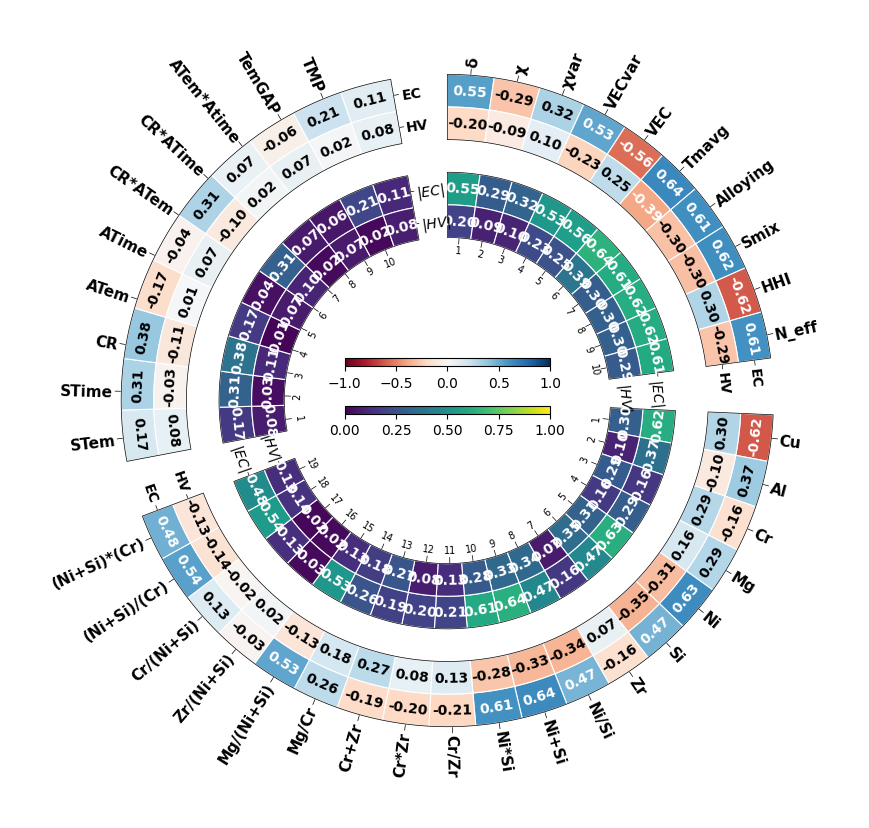

In [11]:
from pycirclize import Circos
import numpy as np
import pandas as pd

# =======================
# 0) Read Excel
# =======================
excel_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/Corr.xlsx"
sheet_name = "Pearson_r"
df = pd.read_excel(excel_path, sheet_name=sheet_name)

# ---- Feature names ----
feature_names = df.iloc[:, 0].astype(str).tolist()

# ---- 指定列：外环 = 原始 HV/EC；内环 = ABS/HV, ABS/EC ----
cols_outer = ["Hardness/HV", "EC/%IACS"]
cols_inner = ["ABS/HV", "ABS/EC"]

M_outer = df[cols_outer].apply(pd.to_numeric, errors="coerce").to_numpy()
M_inner = df[cols_inner].apply(pd.to_numeric, errors="coerce").to_numpy()

# =======================
# 1) Define sectors by Excel row ranges
# =======================
ranges_1based = {
    "A": (21, 30),
    "B": (2, 20),
    "C": (32, 42),
}

sectors = {k: (v[1] - v[0] + 1) for k, v in ranges_1based.items()}
circos = Circos(sectors, space=10)

# =======================
# 2) Labels
# =======================
track1_labels = ["HV", "EC"]          # 外环
track2_labels = [r"$|HV|$", r"$|EC|$"]

# =======================
# 3) Color ranges
# =======================
vmin1, vmax1 = -1, 1   # 外环：相关系数，有正负
vmin2, vmax2 = 0, 1    # 内环：绝对值

# =======================
# 4) Style params
# =======================
OUTER_LABEL_SIZE = 11
OUTER_LABEL_BOLD = True

RADIAL_LABEL_SIZE_T1 = 10
RADIAL_LABEL_SIZE_T2 = 10
RADIAL_LABEL_BOLD = True

VALUE_SIZE_T1 = 10
VALUE_SIZE_T2 = 10
VALUE_BOLD_T1 = True
VALUE_BOLD_T2 = True

RECT_LW_T1 = 0.8
RECT_LW_T2 = 0.8

# =======================
# 5) Plot
# =======================
for sector in circos.sectors:
    name = sector.name
    r1, r2 = ranges_1based[name]

    block_outer = M_outer[r1 - 1:r2, :]       # (rows, 2)
    block_inner = M_inner[r1 - 1:r2, :]       # (rows, 2)
    feats = feature_names[r1 - 1:r2]

    n = min(
        len(feats),
        block_outer.shape[0],
        block_inner.shape[0],
        int(sector.size)
    )

    feats = feats[:n]
    block_outer = block_outer[:n, :]
    block_inner = block_inner[:n, :]

    data_outer = block_outer.T   # shape: (2, n)
    data_inner = block_inner.T   # shape: (2, n)

    x = np.arange(n) + 0.5

    # =======================
    # Track 1: Outer ring
    # =======================
    track1 = sector.add_track((80, 100))
    track1.axis()

    track1.xticks(
        x,
        feats,
        outer=True,
        label_orientation="vertical",
        label_size=OUTER_LABEL_SIZE,
        text_kws=dict(fontweight="bold") if OUTER_LABEL_BOLD else None
    )

    track1.yticks(
        [0.5, 1.5],
        track1_labels,
        vmin=0,
        vmax=2,
        label_size=RADIAL_LABEL_SIZE_T1,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track1.heatmap(
        data_outer,
        vmin=vmin1,
        vmax=vmax1,
        cmap="RdBu",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T1),
        text_kws=(
            dict(size=VALUE_SIZE_T1, fontweight="bold")
            if VALUE_BOLD_T1
            else dict(size=VALUE_SIZE_T1)
        )
    )

    # =======================
    # Track 2: Inner ring
    # =======================
    track2 = sector.add_track((50, 70))
    track2.axis()

    track2.xticks(
        x,
        [str(i + 1) for i in range(n)],
        outer=False,
        label_size=7
    )

    track2.yticks(
        [0.5, 1.5],
        track2_labels,
        vmin=0,
        vmax=2,
        label_size=RADIAL_LABEL_SIZE_T2,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track2.heatmap(
        data_inner,
        vmin=vmin2,
        vmax=vmax2,
        cmap="viridis",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T2),
        text_kws=(
            dict(size=VALUE_SIZE_T2, fontweight="bold")
            if VALUE_BOLD_T2
            else dict(size=VALUE_SIZE_T2)
        )
    )

# =======================
# 6) Colorbars
# =======================
circos.colorbar(
    bounds=(0.35, 0.55, 0.3, 0.012),
    vmin=vmin1,
    vmax=vmax1,
    orientation="horizontal",
    cmap="RdBu"
)

circos.colorbar(
    bounds=(0.35, 0.48, 0.3, 0.012),
    vmin=vmin2,
    vmax=vmax2,
    orientation="horizontal",
    cmap="viridis"
)

# =======================
# 7) Output figure
# =======================
fig = circos.plotfig()

# 保存图片
# fig.savefig(
#     "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/circos_HV_EC_ABS.png",
#     dpi=300,
#     bbox_inches="tight"
# )

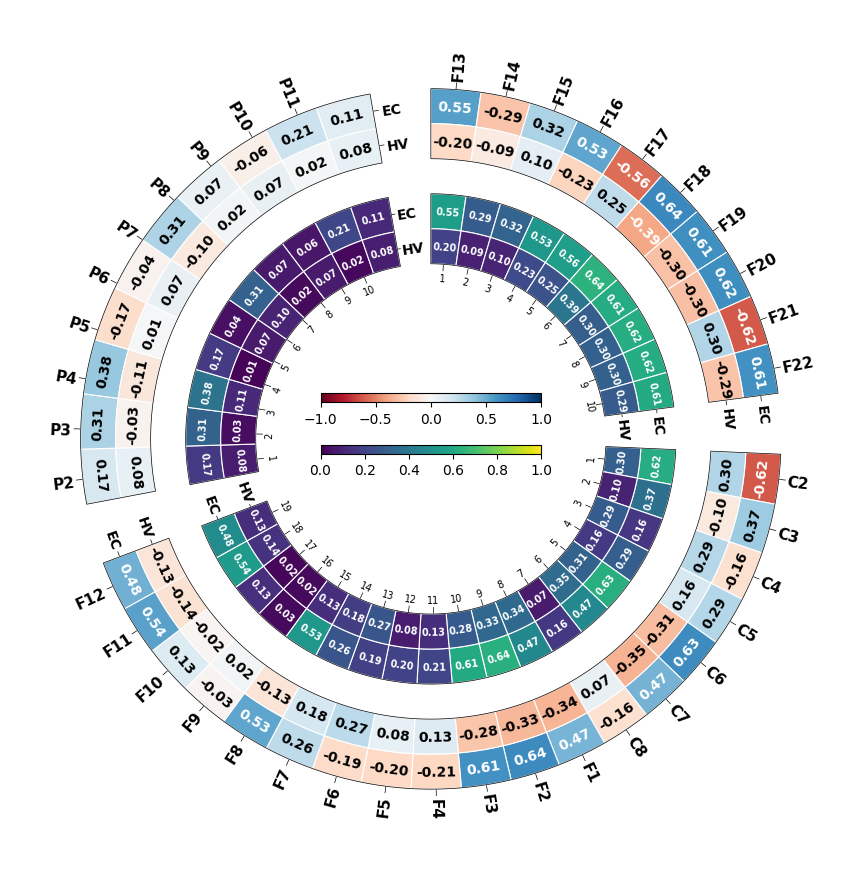

In [18]:
from pycirclize import Circos
import numpy as np
import pandas as pd

# =======================
# 0) Read Excel
# =======================
excel_path = "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/Corr.xlsx"
sheet_name = "Pearson_r"
df = pd.read_excel(excel_path, sheet_name=sheet_name)

feature_names = df.iloc[:, 0].astype(str).tolist()

cols_outer = ["Hardness/HV", "EC/%IACS"]
cols_inner = ["ABS/HV", "ABS/EC"]

M_outer = df[cols_outer].apply(pd.to_numeric, errors="coerce").to_numpy()
M_inner = df[cols_inner].apply(pd.to_numeric, errors="coerce").to_numpy()

# =======================
# 1) Define sectors
# =======================
ranges_1based = {
    "A": (21, 30),
    "B": (2, 20),
    "C": (32, 42),
}

sectors = {k: (v[1] - v[0] + 1) for k, v in ranges_1based.items()}
circos = Circos(sectors, space=10)

# =======================
# 2) Labels
# =======================
track1_labels = ["HV", "EC"]
track2_labels = [r"HV", r"EC"]

# =======================
# 3) Color ranges
# =======================
vmin1, vmax1 = -1, 1
vmin2, vmax2 = 0, 1

# =======================
# 4) Style params
# =======================
OUTER_LABEL_SIZE = 11
OUTER_LABEL_BOLD = True

RADIAL_LABEL_SIZE_T1 = 10
RADIAL_LABEL_SIZE_T2 = 10         # 内环轴向性质标签大一点
RADIAL_LABEL_BOLD = True           # 轴向 HV/EC 和 |HV|/|EC| 加粗

VALUE_SIZE_T1 = 10
VALUE_SIZE_T2 = 7                  # 内环色块数字变小
VALUE_BOLD_T1 = True
VALUE_BOLD_T2 = True

RECT_LW_T1 = 0.8
RECT_LW_T2 = 0.8

# =======================
# 5) Plot
# =======================
for sector in circos.sectors:
    name = sector.name
    r1, r2 = ranges_1based[name]

    block_outer = M_outer[r1 - 1:r2, :]
    block_inner = M_inner[r1 - 1:r2, :]
    feats = feature_names[r1 - 1:r2]

    n = min(len(feats), block_outer.shape[0], block_inner.shape[0], int(sector.size))

    feats = feats[:n]
    block_outer = block_outer[:n, :]
    block_inner = block_inner[:n, :]

    data_outer = block_outer.T
    data_inner = block_inner.T

    x = np.arange(n) + 0.5

    # =======================
    # Track 1: Outer ring
    # =======================
    track1 = sector.add_track((80, 100))
    track1.axis()

    track1.xticks(
        x,
        feats,
        outer=True,
        label_orientation="vertical",
        label_size=OUTER_LABEL_SIZE,
        text_kws=dict(fontweight="bold") if OUTER_LABEL_BOLD else None
    )

    track1.yticks(
        [0.5, 1.5],
        track1_labels,
        vmin=0,
        vmax=2,
        label_size=RADIAL_LABEL_SIZE_T1,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track1.heatmap(
        data_outer,
        vmin=vmin1,
        vmax=vmax1,
        cmap="RdBu",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T1),
        text_kws=(
            dict(size=VALUE_SIZE_T1, fontweight="bold")
            if VALUE_BOLD_T1
            else dict(size=VALUE_SIZE_T1)
        )
    )

    # =======================
    # Track 2: Inner ring
    # =======================
    track2 = sector.add_track((50, 70))
    track2.axis()

    track2.xticks(
        x,
        [str(i + 1) for i in range(n)],
        outer=False,
        label_size=7
    )

    track2.yticks(
        [0.5, 1.5],
        track2_labels,
        vmin=0,
        vmax=2,
        label_size=RADIAL_LABEL_SIZE_T2,
        text_kws=dict(fontweight="bold") if RADIAL_LABEL_BOLD else None
    )

    track2.heatmap(
        data_inner,
        vmin=vmin2,
        vmax=vmax2,
        cmap="viridis",
        show_value=True,
        rect_kws=dict(ec="white", lw=RECT_LW_T2),
        text_kws=(
            dict(size=VALUE_SIZE_T2, fontweight="bold")
            if VALUE_BOLD_T2
            else dict(size=VALUE_SIZE_T2)
        )
    )

# =======================
# 6) Colorbars
# =======================
circos.colorbar(
    bounds=(0.35, 0.55, 0.3, 0.012),
    vmin=vmin1,
    vmax=vmax1,
    orientation="horizontal",
    cmap="RdBu"
)

circos.colorbar(
    bounds=(0.35, 0.48, 0.3, 0.012),
    vmin=vmin2,
    vmax=vmax2,
    orientation="horizontal",
    cmap="viridis"
)

fig = circos.plotfig()

fig.savefig(
    "/Users/zixuanzhao/Desktop/MKG/JMI/JMI-Old/FE/circos_HV_EC_ABS.png",
    dpi=1200,
    bbox_inches="tight"
)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

# ── 1. 读取真实数据 ───────────────────────────────────────────────────────────
df_raw = pd.read_excel("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Feature.xlsx",
                       sheet_name="HV")

# ====================================================
# ✅ 在这里设置你的列范围（Python 从 0 开始计数）
# 例如：第3列到第22列 → columns[2:22]
# ====================================================
feature_start = 1    # 特征起始列索引（含）
feature_end   = 18   # 特征结束列索引（不含）
target_start  = 20   # 性能起始列索引（含）
target_end    = 21   # 性能结束列索引（不含）
# ====================================================

feature_cols = df_raw.columns[feature_start:feature_end]
target_cols  = df_raw.columns[target_start:target_end]

# 合并并去除缺失值
df = df_raw[list(feature_cols) + list(target_cols)].dropna()

variables = list(df.columns)
n = len(variables)   # ✅ 修复：根据实际列数更新 n

# ── 2. 计算 Pearson 相关系数和 p 值 ──────────────────────────────────────────
corr = df.corr(method="pearson")

pval = pd.DataFrame(np.ones((n, n)), index=variables, columns=variables)
for i in range(n):
    for j in range(n):
        if i != j:
            _, p = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
            pval.iloc[i, j] = p

# ── 3. 绘图 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 17))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 颜色映射：蓝(-1) → 白(0) → 红(1)
cmap = plt.cm.RdBu_r
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# 只画下三角（i > j）
for i in range(n):
    for j in range(n):
        if i < j:          # 上三角跳过
            continue
        if i == j:         # 对角线：写变量名
            ax.text(j, i, variables[i],
                    ha="center", va="center",
                    fontsize=23, fontweight="bold", color="#333333")
            continue

        r = corr.iloc[i, j]
        p = pval.iloc[i, j]

        # 圆半径正比于 |r|，最大 0.45
        radius = abs(r) * 0.45
        color  = cmap(norm(r))

        circle = plt.Circle((j, i), radius,
                             color=color, zorder=2)
        ax.add_patch(circle)

        # 显著性星号（p < 0.05）
        if p < 0.05:
            ax.text(j, i, "*",
                    ha="center", va="center",
                    fontsize=23, color="white",
                    fontweight="bold", zorder=3)

# ── 4. 坐标轴设置 ─────────────────────────────────────────────────────────────
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
# ax.set_xticklabels(variables, rotation=90, ha="right", fontsize=13)
ax.set_yticklabels(variables, fontsize=25,fontweight="bold")
ax.invert_yaxis()          # 让第一行在顶部

# 去掉多余边框
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# 浅灰色网格
for i in range(n):
    for j in range(n):
        if i >= j:
            ax.add_patch(mpatches.FancyBboxPatch(
                (j - 0.5, i - 0.5), 1, 1,
                boxstyle="square,pad=0",
                linewidth=0.3, edgecolor="#dddddd",
                facecolor="none", zorder=1))

# ── 5. 颜色条（竖向，右侧）────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02,
                    ticks=[-1, -0.8, -0.6, -0.4, -0.2, 0,
                            0.2, 0.4, 0.6, 0.8, 1])
cbar.ax.tick_params(labelsize=20)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

# # ── 6. 面板标签 & 说明 ────────────────────────────────────────────────────────
# ax.text(0.02, 0.02, "Panel b",
#         transform=ax.transAxes,
#         fontsize=11, fontweight="bold",
#         bbox=dict(boxstyle="square,pad=0.3",
#                   facecolor="white", edgecolor="#aaaaaa"))

ax.set_title("Pearson Correlation Matrix (lower triangle)\n"
             "* p < 0.05   ● size ∝ |r|   color = sign",
             fontsize=10, pad=12)

plt.tight_layout()
plt.savefig("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/correlation_heatmap.png",
            dpi=900, bbox_inches="tight")
plt.show()
print("图像已保存至 correlation_heatmap.png")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Feature.xlsx'

In [96]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


# =========================
# Config
# =========================
excel_path = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Feature.xlsx"   # <- your uploaded file
out_path   = "/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/PermutationImportances_3Sheets.xlsx"

# Permutation settings
N_REPEATS = 30
RANDOM_STATE = 42
SCORING = "r2"   # you can change to "neg_mean_absolute_error" etc.


# =========================
# Helpers
# =========================
def split_cols(X: pd.DataFrame):
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]
    return num_cols, cat_cols

def build_pipeline(X: pd.DataFrame):
    num_cols, cat_cols = split_cols(X)

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=800,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return Pipeline([("pre", pre), ("model", model)])

def run_perm_importance(df_sheet: pd.DataFrame, sheet_name: str) -> pd.DataFrame:
    """
    Auto-detect:
      - col0: ID (ignored)
      - col1..col(-2): features
      - last col: target
    Compute permutation importance on the sheet rows with valid target.
    """
    if df_sheet.shape[1] < 3:
        raise ValueError(f"[{sheet_name}] Need >=3 columns (ID + >=1 feature + target). Got {df_sheet.shape[1]}")

    id_col = df_sheet.columns[0]
    feature_cols = df_sheet.columns[1:-1]
    target_col = df_sheet.columns[-1]

    X = df_sheet.loc[:, feature_cols].copy()
    y = pd.to_numeric(df_sheet[target_col], errors="coerce")

    # keep rows where y is valid
    mask = y.notna()
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()

    # If too few samples, return empty
    if len(y) < 5:
        return pd.DataFrame({
            "Feature": list(feature_cols),
            "ImportanceMean": np.nan,
            "ImportanceStd": np.nan,
            "N_Used": len(y),
            "Target": target_col,
            "Sheet": sheet_name
        })

    pipe = build_pipeline(X)
    pipe.fit(X, y)

    # permutation_importance will permute original input columns (before preprocessing) when used with Pipeline
    result = permutation_importance(
        pipe, X, y,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
        scoring=SCORING
    )

    imp_df = pd.DataFrame({
        "Feature": X.columns,
        "ImportanceMean": result.importances_mean,
        "ImportanceStd": result.importances_std,
    }).sort_values("ImportanceMean", ascending=False)

    imp_df.insert(0, "Sheet", sheet_name)
    imp_df.insert(1, "Target", target_col)
    imp_df.insert(2, "N_Used", len(y))
    imp_df.insert(3, "ID_Column", id_col)
    return imp_df


# =========================
# Main
# =========================
xls = pd.ExcelFile(excel_path)
sheet_names = xls.sheet_names  # should be 3 sheets per your description

all_results = []
per_sheet_results = {}

for s in sheet_names:
    df_s = pd.read_excel(excel_path, sheet_name=s)
    imp = run_perm_importance(df_s, s)
    per_sheet_results[s] = imp
    all_results.append(imp)

all_results_df = pd.concat(all_results, ignore_index=True)

# Save
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # Summary sheet
    all_results_df.to_excel(writer, index=False, sheet_name="ALL_SHEETS")
    # One sheet per model/sheet
    for s, imp_df in per_sheet_results.items():
        safe_name = str(s)[:31]  # Excel sheet name limit
        imp_df.to_excel(writer, index=False, sheet_name=safe_name)

print("Saved:", out_path)
print("Sheets processed:", sheet_names)

Saved: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/PermutationImportances_3Sheets.xlsx
Sheets processed: ['HV', 'EC', 'Q3-Eu']


In [15]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error

# -----------------------------
# 0) Load data
# -----------------------------
excel_path = Path("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Feature3.xlsx")
xls = pd.ExcelFile(excel_path)
sheet_name = "EC" if "EC" in xls.sheet_names else xls.sheet_names[0]
df = pd.read_excel(excel_path, sheet_name=sheet_name)

# -----------------------------
# 1) Auto-detect columns
#    - col0: ID
#    - last col: target
#    - middle: ALL features
# -----------------------------
id_col = df.columns[0]
target_col = df.columns[-1]
feature_cols = list(df.columns[1:-1])      # ✅ 中间全部都是features

# -----------------------------
# 2) Choose k_max (safe & correct)
# -----------------------------
K = len(feature_cols)                      # ✅ 特征总数（比如13）
K_MAX_USER = 15                            # 你想的上限（可改）
k_max = min(K_MAX_USER, K)                 # ✅ 最终枚举到的最大k（这里会是13）

print(f"Sheet: {sheet_name}")
print(f"Target: {target_col}")
print(f"Total features (excluding ID & target): {K}")
print(f"Exhaustive search up to k_max={k_max}")

# -----------------------------
# 3) Prepare X/y
# -----------------------------
y = pd.to_numeric(df[target_col], errors="coerce")
mask = y.notna()
X = df.loc[mask, feature_cols].copy()
y = y.loc[mask].copy()

# Identify numeric/categorical
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

# -----------------------------
# 4) Model pipeline
# -----------------------------
def build_pipe(selected_cols):
    num_sel = [c for c in selected_cols if c in num_cols]
    cat_sel = [c for c in selected_cols if c in cat_cols]

    transformers = []
    if num_sel:
        transformers.append(("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), num_sel))
    if cat_sel:
        transformers.append(("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_sel))

    pre = ColumnTransformer(transformers=transformers, remainder="drop")
    model = Ridge(alpha=1.0, random_state=42)
    return Pipeline([("pre", pre), ("model", model)])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# -----------------------------
# 5) Exhaustive enumeration (1..k_max)
# -----------------------------
results = []
for k in range(1, k_max + 1):              # ✅ 这里保证能到13
    for combo in itertools.combinations(feature_cols, k):
        Xc = X[list(combo)]
        pipe = build_pipe(combo)

        mae_scores = cross_val_score(pipe, Xc, y, cv=cv, scoring=mae_scorer, n_jobs=-1)
        mae = -mae_scores.mean()

        r2_scores = cross_val_score(pipe, Xc, y, cv=cv, scoring="r2", n_jobs=-1)
        r2 = r2_scores.mean()

        results.append({
            "k": k,
            "features": combo,
            "features_str": " + ".join(combo),
            "MAE": float(mae),
            "R2": float(r2),
        })

res_df = pd.DataFrame(results)

# -----------------------------
# 6) Best-by-k curve (clean)
# -----------------------------
best_by_k = res_df.groupby("k", as_index=False).agg(best_MAE=("MAE", "min"))

# Top10 overall (min MAE)
top10 = res_df.sort_values(["MAE", "R2"], ascending=[True, False]).head(10).copy()

# -----------------------------
# 7) Plot (clean, no knee text)
# -----------------------------
fig, ax = plt.subplots(figsize=(7.8, 5.2))

rng = np.random.default_rng(42)
for k, sub in res_df.groupby("k"):
    x = np.full(len(sub), k, dtype=float) + rng.uniform(-0.08, 0.08, size=len(sub))
    ax.scatter(
        x, sub["MAE"],
        marker="o",
        s=26,
        facecolors="none",
        edgecolors="#9AA0A6",
        linewidths=1.0,
        alpha=0.7
    )

# Best per k
ax.plot(best_by_k["k"], best_by_k["best_MAE"], linestyle="--", linewidth=2.0, color="#D62728")
ax.scatter(best_by_k["k"], best_by_k["best_MAE"], s=70, color="#D62728", zorder=5)

ax.set_xlabel("Number of features (k)", fontsize=12)
ax.set_ylabel("5-fold CV MAE (lower is better)", fontsize=12)
ax.set_title(f"Exhaustive feature-combination screening (k=1..{k_max})\nTarget: {target_col}", fontsize=12, pad=10)

# ✅ 每个k都有坐标刻度
ax.set_xticks(list(range(1, k_max + 1)))

# ✅ 关掉网格线
ax.grid(False)

ax.set_xlim(0.5, k_max + 0.5)

plt.tight_layout()

out_png = Path("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/exhaustive_screening_EC.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.close(fig)

out_xlsx = Path("/Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Top10_optimal_feature_combinations_EC.xlsx")
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as w:
    pd.DataFrame({"AllFeaturesUsed": feature_cols}).to_excel(w, index=False, sheet_name="Features")
    best_by_k.to_excel(w, index=False, sheet_name="BestByK")
    top10[["k", "MAE", "R2", "features_str"]].to_excel(w, index=False, sheet_name="Top10_Overall")
    res_df.drop(columns=["features"]).to_excel(w, index=False, sheet_name="AllCombos_1toK")

print("Saved plot:", out_png)
print("Saved results:", out_xlsx)
print("\nTop10 optimal feature combinations:")
print(top10[["k", "MAE", "R2", "features_str"]].to_string(index=False))

Sheet: EC
Target: EC/%IACS
Total features (excluding ID & target): 13
Exhaustive search up to k_max=13
Saved plot: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/exhaustive_screening_EC.png
Saved results: /Users/zixuanzhao/Desktop/MKG/JMI邀稿文章/FeatureEngineering/Top10_optimal_feature_combinations_EC.xlsx

Top10 optimal feature combinations:
 k      MAE       R2                                                                 features_str
 9 8.139363 0.279220          Ni/wt.% + Ni/Si + Ni*Si + Smix + N_eff + HHI + δ + Alloying + Mg/Cr
 8 8.140911 0.280007                  Ni/wt.% + Ni*Si + Smix + N_eff + HHI + δ + Alloying + Mg/Cr
 8 8.142564 0.278674                Ni/wt.% + Ni/Si + Ni*Si + Smix + N_eff + δ + Alloying + Mg/Cr
 8 8.143714 0.261536                  Ni/wt.% + Ni/Si + Ni*Si + Cr+Zr + Smix + N_eff + δ + VECavg
 7 8.144344 0.279432                        Ni/wt.% + Ni*Si + Smix + N_eff + δ + Alloying + Mg/Cr
 7 8.144543 0.276434                          Ni/wt.% + Ni*S